In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("../data/data.csv")

df.head()

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 150150
Columns: 9


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150150 entries, 0 to 150149
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   record_ID        150150 non-null  int64  
 1   week             150150 non-null  str    
 2   store_id         150150 non-null  int64  
 3   sku_id           150150 non-null  int64  
 4   total_price      150149 non-null  float64
 5   base_price       150150 non-null  float64
 6   is_featured_sku  150150 non-null  int64  
 7   is_display_sku   150150 non-null  int64  
 8   units_sold       150150 non-null  int64  
dtypes: float64(2), int64(6), str(1)
memory usage: 11.5 MB


In [8]:
df.isnull().sum()

record_ID          0
week               0
store_id           0
sku_id             0
total_price        1
base_price         0
is_featured_sku    0
is_display_sku     0
units_sold         0
dtype: int64

In [9]:
df.describe()

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
count,150150.000000,150150.000000,150150.000000,150149.000000,150150.000000,150150.000000,150150.000000,150150.000000
mean,106271.555504,9199.422511,254761.132468,206.626751,219.425927,0.095611,0.133200,51.674206
std,61386.037861,615.591445,85547.306447,103.308516,110.961712,0.294058,0.339792,60.207904
min,1.000000,8023.000000,216233.000000,41.325000,61.275000,0.000000,0.000000,1.000000
25%,53111.250000,8562.000000,217217.000000,130.387500,133.237500,0.000000,0.000000,20.000000
50%,106226.500000,9371.000000,222087.000000,198.075000,205.912500,0.000000,0.000000,35.000000
75%,159452.750000,9731.000000,245338.000000,233.700000,234.412500,0.000000,0.000000,62.000000
max,212644.000000,9984.000000,679023.000000,562.162500,562.162500,1.000000,1.000000,2876.000000


In [10]:
df['week'] = pd.to_datetime(df['week'], dayfirst=True)

print(df['week'].min())
print(df['week'].max())

2011-01-17 00:00:00
2013-07-09 00:00:00


C:\Users\HARSHITH\AppData\Local\Temp\ipykernel_20684\3280158671.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['week'] = pd.to_datetime(df['week'], dayfirst=True)


In [11]:
print("Number of stores:", df['store_id'].nunique())

Number of stores: 76


In [12]:
print("Number of SKUs:", df['sku_id'].nunique())

Number of SKUs: 28


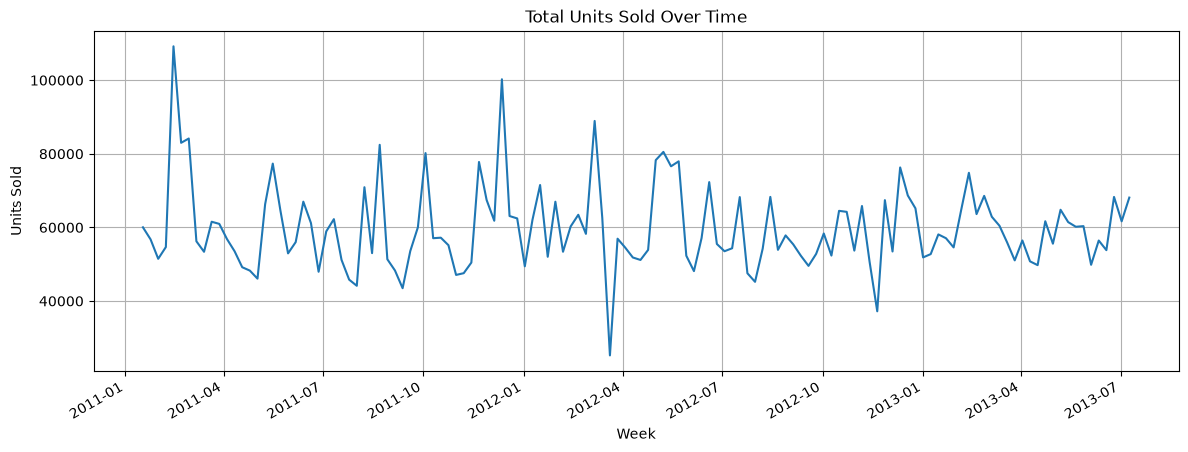

In [13]:
df.groupby('week')['units_sold'].sum().plot(figsize=(14, 5))

plt.title('Total Units Sold Over Time')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.grid(True)
plt.show()

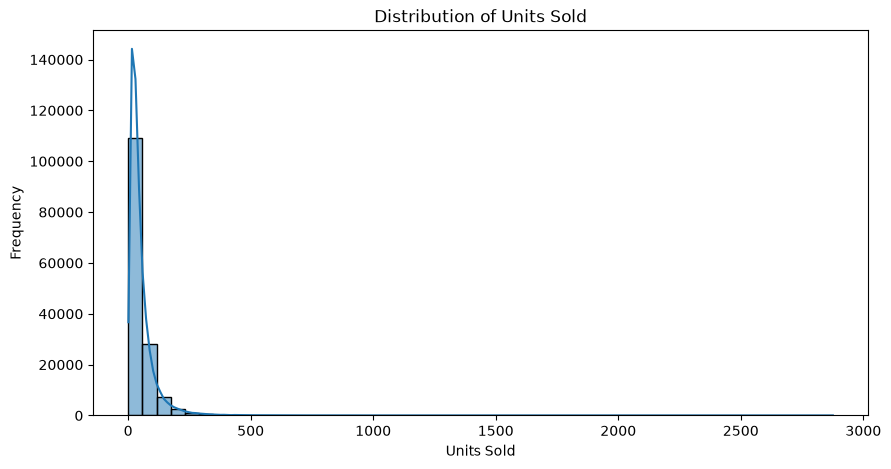

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(df['units_sold'], bins=50, kde=True)

plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')

plt.show()

In [15]:
print("Number of stores:", df['store_id'].nunique())

Number of stores: 76


In [16]:
print("Number of SKUs:", df['sku_id'].nunique())

Number of SKUs: 28


In [17]:
print("Start date:", df['week'].min())
print("End date:", df['week'].max())
print("Number of weeks:", df['week'].nunique())

Start date: 2011-01-17 00:00:00
End date: 2013-07-09 00:00:00
Number of weeks: 130


In [18]:
sku_counts = df.groupby('sku_id')['week'].nunique()

print(sku_counts.describe())

count     28.0
mean     130.0
std        0.0
min      130.0
25%      130.0
50%      130.0
75%      130.0
max      130.0
Name: week, dtype: float64


In [19]:
combination_counts = (
    df.groupby(['store_id', 'sku_id'])['week']
      .nunique()
)

print("Number of Store-SKU combinations:", len(combination_counts))
print("\nWeeks per combination:")
print(combination_counts.value_counts().sort_index())

Number of Store-SKU combinations: 1155

Weeks per combination:
week
130    1155
Name: count, dtype: int64


In [20]:
sample = df[
    (df['store_id'] == 8091) &
    (df['sku_id'] == 216418)
].sort_values('week')

sample[['week', 'total_price', 'base_price',
        'is_featured_sku', 'is_display_sku',
        'units_sold']].head(15)

,week,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,2011-01-17,99.0375,111.8625,0,0,20
1155,2011-01-24,99.0375,111.8625,0,0,34
2310,2011-01-31,96.9000,96.9000,0,0,10
3465,2011-02-07,98.3250,98.3250,0,0,17
4620,2011-02-14,106.8750,106.8750,0,0,24
5775,2011-02-21,106.1625,106.1625,0,0,29
6930,2011-02-28,106.1625,106.1625,0,0,16
8085,2011-03-07,106.1625,106.1625,0,0,14
9240,2011-03-14,99.0375,99.0375,0,0,20
10395,2011-03-21,105.4500,105.4500,0,0,18


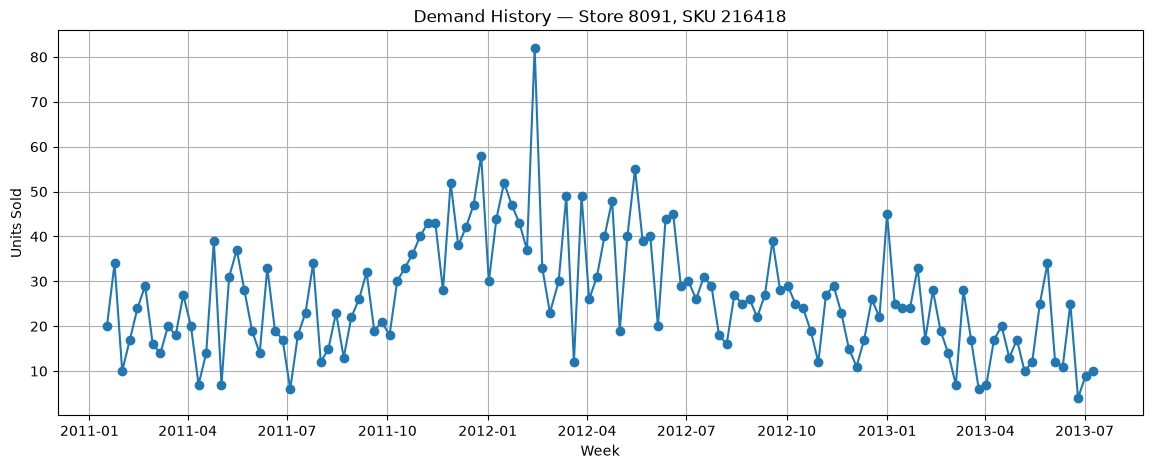

In [21]:
plt.figure(figsize=(14, 5))

plt.plot(
    sample['week'],
    sample['units_sold'],
    marker='o'
)

plt.title('Demand History — Store 8091, SKU 216418')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.grid(True)

plt.show()

In [22]:
df = df.sort_values(
    ['store_id', 'sku_id', 'week']
).reset_index(drop=True)

In [23]:
df['year'] = df['week'].dt.year
df['month'] = df['week'].dt.month
df['week_of_year'] = df['week'].dt.isocalendar().week.astype(int)

In [24]:
group = df.groupby(['store_id', 'sku_id'])['units_sold']

df['lag_1'] = group.shift(1)
df['lag_2'] = group.shift(2)
df['lag_4'] = group.shift(4)
df['lag_8'] = group.shift(8)

In [25]:
df['rolling_mean_4'] = (
    df.groupby(['store_id', 'sku_id'])['units_sold']
      .transform(lambda x: x.shift(1).rolling(4).mean())
)

df['rolling_mean_8'] = (
    df.groupby(['store_id', 'sku_id'])['units_sold']
      .transform(lambda x: x.shift(1).rolling(8).mean())
)

In [26]:
df[
    [
        'week',
        'store_id',
        'sku_id',
        'units_sold',
        'lag_1',
        'lag_2',
        'lag_4',
        'lag_8',
        'rolling_mean_4',
        'rolling_mean_8'
    ]
].head(20)

,week,store_id,sku_id,units_sold,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_mean_8
0,2011-01-17,8023,216233,114,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-01-24,8023,216233,87,114.0,NaN,NaN,NaN,NaN,NaN
2,2011-01-31,8023,216233,135,87.0,114.0,NaN,NaN,NaN,NaN
3,2011-02-07,8023,216233,115,135.0,87.0,NaN,NaN,NaN,NaN
4,2011-02-14,8023,216233,93,115.0,135.0,114.0,NaN,112.75,NaN
5,2011-02-21,8023,216233,150,93.0,115.0,87.0,NaN,107.50,NaN
6,2011-02-28,8023,216233,134,150.0,93.0,135.0,NaN,123.25,NaN
7,2011-03-07,8023,216233,130,134.0,150.0,115.0,NaN,123.00,NaN
8,2011-03-14,8023,216233,167,130.0,134.0,93.0,114.0,126.75,119.750
9,2011-03-21,8023,216233,126,167.0,130.0,150.0,87.0,145.25,126.375


In [27]:
print(df[['lag_1', 'lag_2', 'lag_4', 'lag_8',
          'rolling_mean_4', 'rolling_mean_8']].isnull().sum())

lag_1             1155
lag_2             2310
lag_4             4620
lag_8             9240
rolling_mean_4    4620
rolling_mean_8    9240
dtype: int64


In [28]:
df_model = df.dropna().copy()

In [29]:
print("Original rows:", len(df))
print("Model rows:", len(df_model))
print("Rows removed:", len(df) - len(df_model))

Original rows: 150150
Model rows: 140909
Rows removed: 9241


In [30]:
features = [
    'store_id',
    'sku_id',
    'total_price',
    'base_price',
    'is_featured_sku',
    'is_display_sku',
    'year',
    'month',
    'week_of_year',
    'lag_1',
    'lag_2',
    'lag_4',
    'lag_8',
    'rolling_mean_4',
    'rolling_mean_8'
]

target = 'units_sold'

In [31]:
cutoff_date = df_model['week'].sort_values().unique()[-26]

train = df_model[df_model['week'] < cutoff_date].copy()
test = df_model[df_model['week'] >= cutoff_date].copy()

print("Training period:")
print(train['week'].min(), "→", train['week'].max())

print("\nTesting period:")
print(test['week'].min(), "→", test['week'].max())

print("\nTraining rows:", len(train))
print("Testing rows:", len(test))

Training period:
2011-03-14 00:00:00 → 2013-01-08 00:00:00

Testing period:
2013-01-15 00:00:00 → 2013-07-09 00:00:00

Training rows: 110880
Testing rows: 30029


In [32]:
from xgboost import XGBRegressor

In [33]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    eval_metric='mae',
    random_state=42,
    n_jobs=-1
)

In [34]:
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

NameError: name 'X_train' is not defined

In [35]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (110880, 15)
y_train: (110880,)
X_test: (30029, 15)
y_test: (30029,)


In [36]:
from xgboost import XGBRegressor

In [37]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    eval_metric='mae',
    random_state=42,
    n_jobs=-1
)

In [38]:
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'mae'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [39]:
y_pred = xgb_model.predict(X_test)

print(y_pred[:10])

[111.40459  96.58924 147.05618 127.80248 124.40782 111.5293  100.352
 109.25853 123.00429 183.44899]


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

# Ignore zero-demand observations for MAPE
mask = y_test != 0

mape = np.mean(
    np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])
) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 14.76
RMSE : 25.98
MAPE : 47.07%


In [41]:
results = test[
    ['week', 'store_id', 'sku_id', 'units_sold']
].copy()

results['predicted_demand'] = y_pred

results.head(20)

,week,store_id,sku_id,units_sold,predicted_demand
104,2013-01-15,8023,216233,141,111.404587
105,2013-01-22,8023,216233,117,96.589241
106,2013-01-29,8023,216233,115,147.056183
107,2013-02-05,8023,216233,122,127.802483
108,2013-02-12,8023,216233,111,124.407822
109,2013-02-19,8023,216233,103,111.529297
110,2013-02-26,8023,216233,124,100.351997
111,2013-03-05,8023,216233,71,109.258530
112,2013-03-12,8023,216233,214,123.004288
113,2013-03-19,8023,216233,146,183.448990


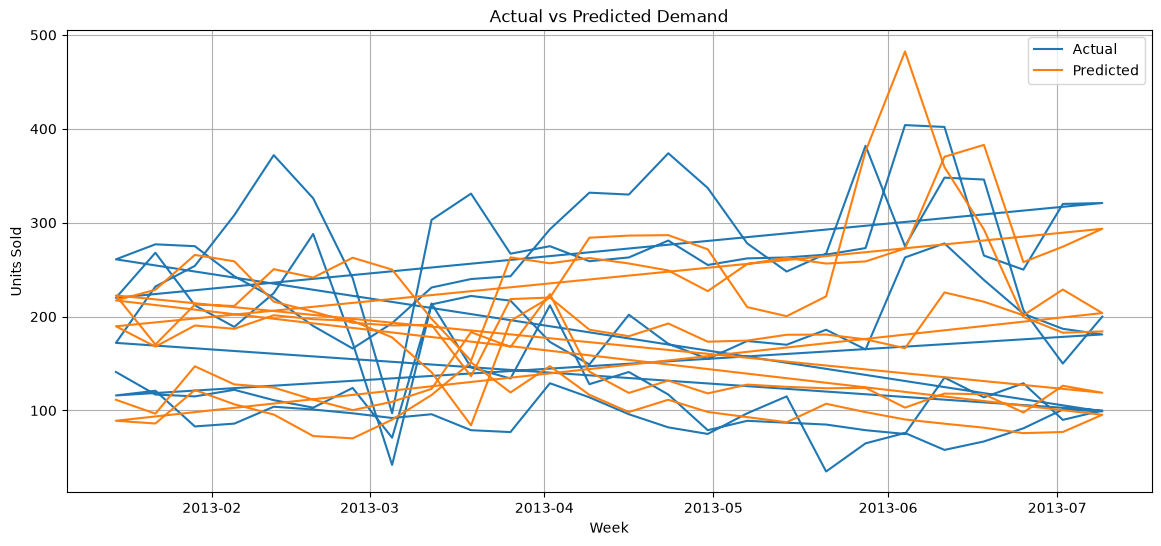

In [42]:
plt.figure(figsize=(14, 6))

plt.plot(
    results['week'].iloc[:130],
    results['units_sold'].iloc[:130],
    label='Actual'
)

plt.plot(
    results['week'].iloc[:130],
    results['predicted_demand'].iloc[:130],
    label='Predicted'
)

plt.title('Actual vs Predicted Demand')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)

plt.show()

In [43]:
wape = (
    np.sum(np.abs(y_test - y_pred))
    / np.sum(np.abs(y_test))
) * 100

print(f"WAPE : {wape:.2f}%")

WAPE : 28.58%


In [44]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

is_featured_sku    0.293456
lag_1              0.160066
rolling_mean_8     0.122353
is_display_sku     0.082048
rolling_mean_4     0.073442
total_price        0.046188
sku_id             0.043938
base_price         0.041090
week_of_year       0.029721
lag_8              0.027976
month              0.023001
year               0.022084
lag_2              0.012596
lag_4              0.012354
store_id           0.009688
dtype: float32


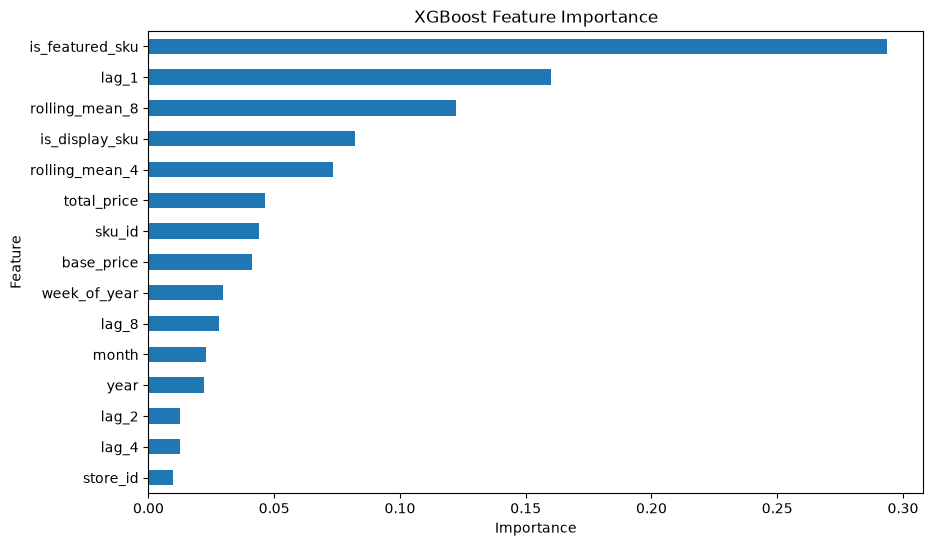

In [45]:
plt.figure(figsize=(10, 6))

importance.sort_values().plot(kind='barh')

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

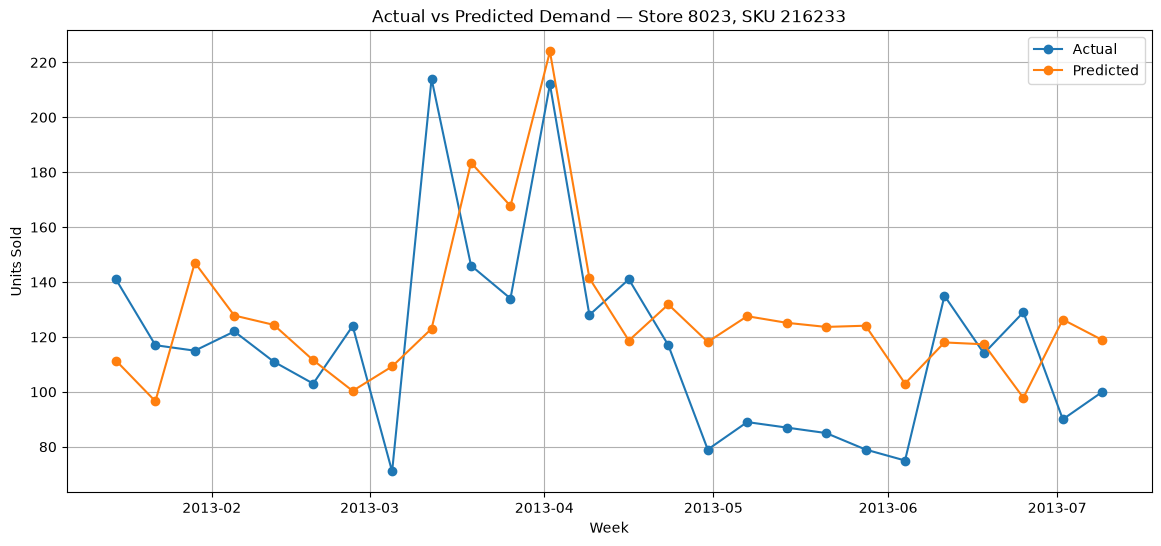

In [46]:
sample_result = results[
    (results['store_id'] == 8023) &
    (results['sku_id'] == 216233)
].sort_values('week')

plt.figure(figsize=(14, 6))

plt.plot(
    sample_result['week'],
    sample_result['units_sold'],
    marker='o',
    label='Actual'
)

plt.plot(
    sample_result['week'],
    sample_result['predicted_demand'],
    marker='o',
    label='Predicted'
)

plt.title('Actual vs Predicted Demand — Store 8023, SKU 216233')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)

plt.show()

In [47]:
naive_pred = X_test['lag_1'].values

naive_mae = mean_absolute_error(y_test, naive_pred)

naive_rmse = np.sqrt(
    mean_squared_error(y_test, naive_pred)
)

naive_wape = (
    np.sum(np.abs(y_test - naive_pred))
    / np.sum(np.abs(y_test))
) * 100

print(f"Naive MAE  : {naive_mae:.2f}")
print(f"Naive RMSE : {naive_rmse:.2f}")
print(f"Naive WAPE : {naive_wape:.2f}%")

Naive MAE  : 19.87
Naive RMSE : 40.00
Naive WAPE : 38.48%


In [48]:
xgb_wape = (
    np.sum(np.abs(y_test - y_pred))
    / np.sum(np.abs(y_test))
) * 100

print(f"XGBoost MAE  : {mae:.2f}")
print(f"XGBoost RMSE : {rmse:.2f}")
print(f"XGBoost WAPE : {xgb_wape:.2f}%")

XGBoost MAE  : 14.76
XGBoost RMSE : 25.98
XGBoost WAPE : 28.58%


In [49]:
df['discount_pct'] = (
    (df['base_price'] - df['total_price'])
    / df['base_price']
) * 100

In [50]:
group = df.groupby(
    ['store_id', 'sku_id']
)['units_sold']

df['lag_13'] = group.shift(13)
df['lag_26'] = group.shift(26)

In [51]:
df['demand_trend'] = df['lag_1'] - df['lag_4']

In [52]:
df['rolling_std_4'] = (
    df.groupby(['store_id', 'sku_id'])['units_sold']
      .transform(
          lambda x: x.shift(1).rolling(4).std()
      )
)

df['rolling_std_8'] = (
    df.groupby(['store_id', 'sku_id'])['units_sold']
      .transform(
          lambda x: x.shift(1).rolling(8).std()
      )
)

In [53]:
df['price_ratio'] = (
    df['total_price'] / df['base_price']
)

In [54]:
df_model_v2 = df.dropna().copy()

print("Original rows:", len(df))
print("Version 2 rows:", len(df_model_v2))

Original rows: 150150
Version 2 rows: 120119


In [55]:
features_v2 = [
    'store_id',
    'sku_id',
    'total_price',
    'base_price',
    'discount_pct',
    'price_ratio',
    'is_featured_sku',
    'is_display_sku',
    'year',
    'month',
    'week_of_year',
    'lag_1',
    'lag_2',
    'lag_4',
    'lag_8',
    'lag_13',
    'lag_26',
    'rolling_mean_4',
    'rolling_mean_8',
    'rolling_std_4',
    'rolling_std_8',
    'demand_trend'
]

target = 'units_sold'

In [56]:
cutoff_date = df_model_v2['week'].sort_values().unique()[-26]

train_v2 = df_model_v2[
    df_model_v2['week'] < cutoff_date
].copy()

test_v2 = df_model_v2[
    df_model_v2['week'] >= cutoff_date
].copy()

X_train_v2 = train_v2[features_v2]
y_train_v2 = train_v2[target]

X_test_v2 = test_v2[features_v2]
y_test_v2 = test_v2[target]

print("Train:", X_train_v2.shape)
print("Test :", X_test_v2.shape)

Train: (90090, 22)
Test : (30029, 22)


In [57]:
xgb_model_v2 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    eval_metric='mae',
    random_state=42,
    n_jobs=-1
)

xgb_model_v2.fit(
    X_train_v2,
    y_train_v2,
    eval_set=[(X_test_v2, y_test_v2)],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'mae'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [58]:
y_pred_v2 = xgb_model_v2.predict(X_test_v2)

In [59]:
mae_v2 = mean_absolute_error(
    y_test_v2,
    y_pred_v2
)

rmse_v2 = np.sqrt(
    mean_squared_error(
        y_test_v2,
        y_pred_v2
    )
)

wape_v2 = (
    np.sum(
        np.abs(y_test_v2 - y_pred_v2)
    )
    /
    np.sum(
        np.abs(y_test_v2)
    )
) * 100

print(f"Version 2 MAE  : {mae_v2:.2f}")
print(f"Version 2 RMSE : {rmse_v2:.2f}")
print(f"Version 2 WAPE : {wape_v2:.2f}%")

Version 2 MAE  : 14.61
Version 2 RMSE : 25.85
Version 2 WAPE : 28.30%


In [60]:
importance_v2 = pd.Series(
    xgb_model_v2.feature_importances_,
    index=features_v2
).sort_values(ascending=False)

print(importance_v2)

is_featured_sku    0.276113
lag_1              0.146735
rolling_mean_8     0.112693
price_ratio        0.071071
rolling_mean_4     0.059425
is_display_sku     0.058888
discount_pct       0.037660
sku_id             0.024344
week_of_year       0.021768
year               0.021298
total_price        0.021107
rolling_std_8      0.021105
lag_8              0.018767
base_price         0.018393
month              0.018223
lag_13             0.015407
lag_26             0.014800
demand_trend       0.010564
lag_4              0.008961
rolling_std_4      0.008891
lag_2              0.008524
store_id           0.005261
dtype: float32


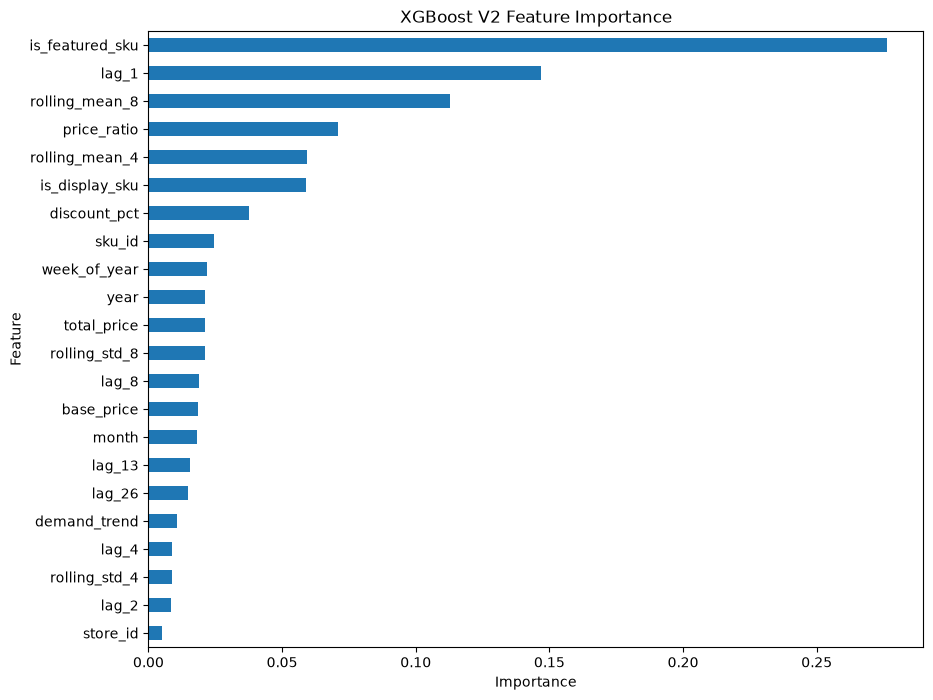

In [61]:
plt.figure(figsize=(10, 8))

importance_v2.sort_values().plot(kind='barh')

plt.title('XGBoost V2 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()